In [1]:
%load_ext autoreload
%autoreload 2

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import halfnorm

In [24]:
from simulators import NestedModelFamily
from simulators.benchmarks import DDM
from adapters import Adapter

In [25]:
from networks.transformers.encoder import Encoder
from networks.transformers.decoder import Decoder
from networks.transformers.gpt import BayesGPTv2

In [26]:
ddm_priors = {
    "v":        {"intercept": lambda: np.random.gamma(2., 1.),
                 "slope": lambda: 0.0},
    "a":        {"intercept": lambda: np.random.normal(-1, 0.3),
                 "slope": lambda: 0.0},
    "tau":      {"intercept": lambda: np.random.normal(-1.5, 0.3),
                 "slope": lambda: 0.0},
    "s_v":      {"intercept": lambda: halfnorm.rvs(loc=0.0, scale=1.0),
                 "slope": lambda: 0.0},
    "s_tau":    {"intercept": lambda: np.random.beta(1.0, 3.0),
                 "slope": lambda: 0.0}
}

In [27]:
ddm_full_priors = {
    "v": {"intercept": lambda: np.random.gamma(2., 1.),
          "slope": lambda: np.random.normal(0., 1.)},
    "a": {"intercept": lambda: np.random.normal(-1, 0.3),
          "slope": lambda: np.random.normal(0., 1.)},
    "tau": {"intercept": lambda: np.random.normal(-1.5, 0.3),
            "slope": lambda: np.random.normal(0., 1.)},
    "s_v": {"intercept": lambda: halfnorm.rvs(loc=0.0, scale=1.0),
            "slope": lambda: np.random.normal(0., 1.)},
    "s_tau": {"intercept": lambda: np.random.beta(1.0, 3.0),
              "slope": lambda: np.random.normal(0., 1.)}
}

In [28]:
model_family = NestedModelFamily(name="DDM", model=DDM(), prior_fun=ddm_full_priors)

In [49]:
samples = model_family.batch_sample(
    batch_size=80,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "a", "tau", "s_v", "s_tau"},
        fixed_intrinsics={}
    ),
    num_obs=500,
    flatten_param_outputs=True
)

In [50]:
samples.keys()

dict_keys(['model_names', 'design_configs', 'design_matrices', 'param_masks', 'param_matrices', 'sim_data', 'regressor_masks', 'discrete_masks', 'num_obs', 'num_regressors', 'max_num_regressors', 'max_num_categories'])

In [51]:
samples["param_matrices"].shape

(80, 80)

In [52]:
samples["param_matrices"]

array([[ 2.35359931, -0.74239455, -1.25999614, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.71550572, -0.93933409, -0.82489672, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.39674925, -0.71902534, -1.58793846, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.69139079, -0.5243449 , -1.53894437, ...,  0.        ,
         0.        ,  0.        ],
       [ 2.8422361 , -1.20282362, -1.08362484, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.0335722 , -0.93813772, -0.85962133, ...,  0.        ,
         0.        ,  0.        ]], shape=(80, 80))

<Axes: >

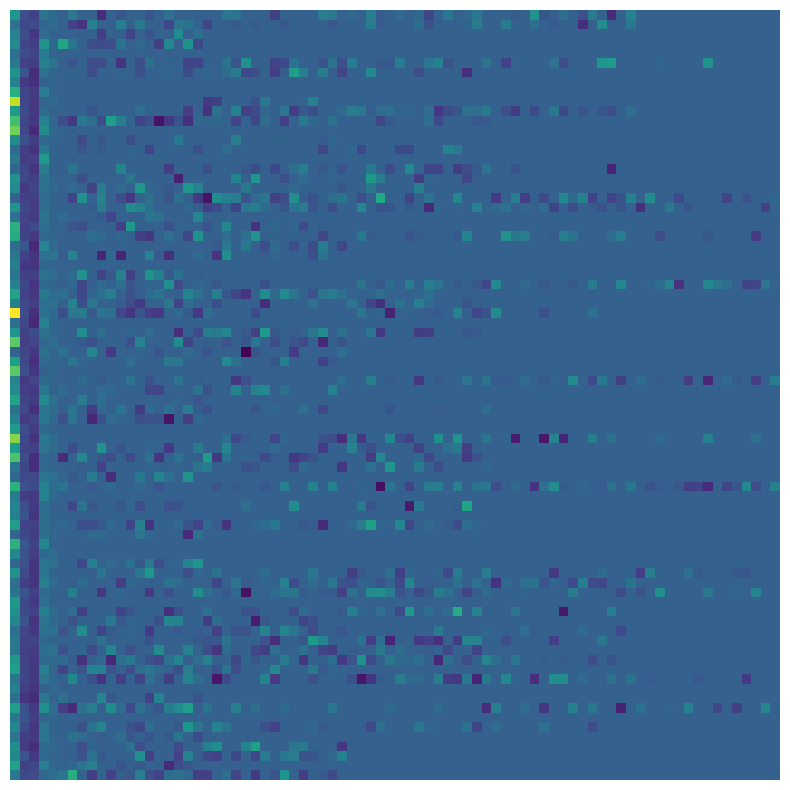

In [59]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.heatmap(samples["param_matrices"], cbar=False, xticklabels=False, yticklabels=False, cmap="viridis", square=True)

In [53]:
samples["param_masks"].shape

(80, 80)

In [54]:
samples["param_masks"]

array([[1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.]], shape=(80, 80))

<Axes: >

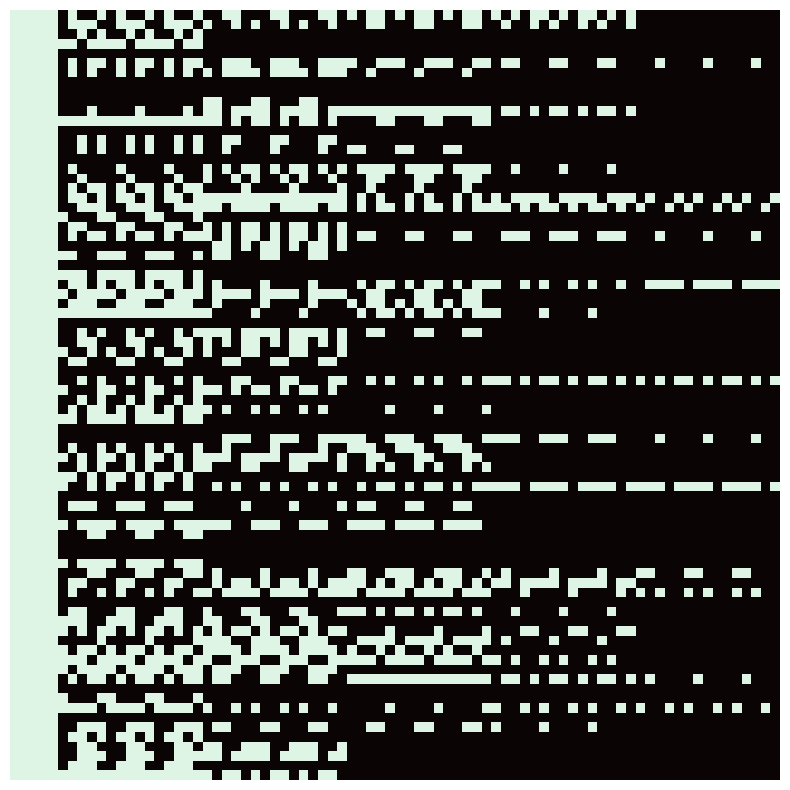

In [56]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
sns.heatmap(samples["param_masks"], cbar=False, xticklabels=False, yticklabels=False, cmap="mako", square=True)

In [47]:
samples["design_configs"]

[{'1': ['v', 'a', 'tau', 's_v', 's_tau'],
  'u_1': ['a', 's_tau'],
  'u_2': ['v', 's_v', 's_tau']},
 {'1': ['v', 'a', 'tau', 's_v', 's_tau'],
  'u_1': ['a'],
  'u_2': ['v', 'a', 's_v', 's_tau'],
  'u_3': ['a', 's_tau'],
  'u_4': ['v', 'tau', 's_v'],
  'u_5': ['s_v', 's_tau']},
 {'1': ['v', 'a', 'tau', 's_v', 's_tau'],
  'u_1': ['v', 'a', 'tau', 's_v'],
  'u_2': ['s_v', 's_tau'],
  'u_3': ['v', 'a', 'tau', 's_v'],
  'u_4': ['v', 'a', 'tau', 's_v'],
  'u_5': ['a', 'tau', 's_v']},
 {'1': ['v', 'a', 'tau', 's_v', 's_tau'],
  'u_1': ['v'],
  'u_2': ['a'],
  'u_3': ['v', 's_tau'],
  'u_4': ['v', 'a', 's_v']},
 {'1': ['v', 'a', 'tau', 's_v', 's_tau']},
 {'1': ['v', 'a', 'tau', 's_v', 's_tau'],
  'u_1': ['s_v', 's_tau'],
  'u_2': ['v'],
  'u_3': ['a', 's_tau']},
 {'1': ['v', 'a', 'tau', 's_v', 's_tau'], 'u_1': ['v', 'a', 's_v']},
 {'1': ['v', 'a', 'tau', 's_v', 's_tau'],
  'u_1': ['tau', 's_v'],
  'u_2': ['v', 'a', 'tau', 's_v', 's_tau']},
 {'1': ['v', 'a', 'tau', 's_v', 's_tau']},
 {'1': ['v'

In [20]:
adapter = Adapter()

In [38]:
adapted_data = adapter.adapt(samples, intrinsic_params=list(ddm_full_priors.keys()))

In [39]:
adapted_data.keys()

dict_keys(['input_data', 'param_indices', 'regressor_indices', 'param_masks', 'param_matrices', 'token_embeddings'])

In [40]:
adapted_data["param_masks"]

tensor([[1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0.,
         0., 1., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
         0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
         1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 1.,
         0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0.,
         0., 1., 1., 0., 0., 0., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1.,
         1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1.,
         1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
         0., 1., 1., 1., 

In [41]:
adapted_data["param_matrices"]

tensor([[ 1.7375e+00, -1.0483e+00, -1.8659e+00,  9.3239e-01,  1.4892e-01,
          0.0000e+00,  2.4073e-01,  0.0000e+00,  0.0000e+00,  5.2207e-01,
          0.0000e+00,  4.6062e-01,  0.0000e+00,  0.0000e+00,  1.9669e-01,
          0.0000e+00, -6.8338e-01,  0.0000e+00,  0.0000e+00, -1.3463e+00,
          7.3382e-01,  0.0000e+00,  0.0000e+00, -3.4460e-01,  1.4654e+00,
          1.5059e+00,  0.0000e+00,  0.0000e+00,  1.4799e-01, -1.1296e+00,
         -6.9586e-01,  0.0000e+00,  0.0000e+00,  2.9393e-01, -8.0207e-01,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.

In [43]:
print(adapted_data["param_masks"].shape, adapted_data["param_matrices"].shape)

torch.Size([10, 80]) torch.Size([10, 80])


In [60]:
adapted_data["input_data"].shape

torch.Size([10, 500, 17])

#### Hyperparams

In [22]:
grad_clip_norm = 5.
batch_size = 32
epochs = 100
steps_per_epoch = 100
learning_rate = 2e-4

In [32]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [44]:
net_kwargs = {
    "encoder_num_layers": 8,
    "decoder_num_layers": 8,
    "encoder_num_heads": 8,
    "decoder_num_heads": 8,
    "num_seeds": 40,
    "seed_dim": 128,
    "proj_dim": 64,
    "dropout": 0.1,
    "layer_dropout": 0.1,
}

In [62]:
input_data = adapted_data["input_data"]

In [66]:
encoder = Encoder(input_dim=17)

In [67]:
encoder_token = encoder(input_data)

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)